# Classificação de Gênero de Livros com Machine Learning

Este notebook apresenta a construção de um modelo de Machine Learning capaz de classificar o gênero de livros com base em seus títulos e sinopses.

O problema abordado é de **classificação supervisionada**, onde o objetivo é prever a categoria (gênero) a partir de dados textuais.

Serão utilizadas técnicas clássicas de Machine Learning com a biblioteca Scikit-Learn, incluindo:
- Pré-processamento de dados
- Vetorização de texto (TF-IDF)
- Modelagem com diferentes algoritmos
- Validação cruzada
- Otimização de hiperparâmetros
- Avaliação de desempenho
- Exportação do modelo final

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report

## Carregamento dos Dados

Os dados foram carregados a partir de um arquivo CSV contendo informações sobre livros.

In [63]:
url = "https://raw.githubusercontent.com/stephaniefay/s4-mvp/refs/heads/main/backend/Machine%20Learning/dataset/data.csv"
dataset = pd.read_csv(url)

dataset.head()

,Unnamed: 0,title,rating,name,num_ratings,num_reviews,num_followers,synopsis,genre
0,0,Sapiens: A Brief History of Humankind,4.39,Yuval Noah Harari,"8,06,229","46,149",30.5k,"100,000 years ago, at least six human species ...",history
1,1,"Guns, Germs, and Steel: The Fates of Human Soc...",4.04,Jared Diamond,"3,67,056","12,879","6,538","""Diamond has written a book of remarkable scop...",history
2,2,A People's History of the United States,4.07,Howard Zinn,"2,24,620","6,509","2,354","In the book, Zinn presented a different side o...",history
3,3,"The Devil in the White City: Murder, Magic, an...",3.99,Erik Larson,"6,13,157","36,644",64.2k,Author Erik Larson imbues the incredible event...,history
4,4,The Diary of a Young Girl,4.18,Anne Frank,"33,13,033","35,591","4,621",Discovered in the attic in which she spent the...,history


## Análise Inicial dos Dados

Nesta etapa, analisamos a estrutura da base de dados e verificamos possíveis valores ausentes.

In [64]:
dataset.info()
dataset.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1539 entries, 0 to 1538
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     1539 non-null   int64  
 1   title          1539 non-null   object 
 2   rating         1539 non-null   float64
 3   name           1539 non-null   object 
 4   num_ratings    1539 non-null   object 
 5   num_reviews    1539 non-null   object 
 6   num_followers  1539 non-null   object 
 7   synopsis       1539 non-null   object 
 8   genre          1539 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 108.3+ KB


,0
Unnamed: 0,0
title,0
rating,0
name,0
num_ratings,0
num_reviews,0
num_followers,0
synopsis,0
genre,0


## Pré-processamento dos Dados

Foi criada uma nova variável textual combinando o título e a sinopse dos livros, além de remover registros com valores ausentes.

In [65]:
dataset = dataset.dropna()

dataset['text'] = dataset['title'] + " " + dataset['synopsis']

X = dataset['text']
y = dataset['genre']

## Separação dos Dados (Holdout)

Os dados foram divididos em:
- 80% treino
- 20% teste

Foi utilizada estratificação para manter a proporção das classes.

In [66]:
test_size = 0.20
seed = 7

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    stratify=y,
    random_state=seed
)

## Validação Cruzada

Será utilizada validação cruzada estratificada com 10 partições.

In [67]:
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=7)

## Modelos Utilizados

Serão avaliados os seguintes algoritmos:
- KNN
- Árvore de Decisão
- Naive Bayes
- SVM

Foi utilizada a técnica de Pipeline para integrar o TF-IDF com os modelos.

In [68]:
models = [
    ("KNN", Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("clf", KNeighborsClassifier())
    ])),

    ("Decision Tree", Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("clf", DecisionTreeClassifier(random_state=7))
    ])),

    ("Naive Bayes", Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("clf", MultinomialNB())
    ])),

    ("SVM", Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("clf", SVC(kernel='linear'))
    ])),
]

## Avaliação dos Modelos

Os modelos serão avaliados utilizando validação cruzada com a métrica de acurácia.

In [69]:
results = []
names = []

for name, model in models:
    scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring="accuracy")

    results.append(scores)
    names.append(name)

    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

KNN: 0.6190 (+/- 0.0263)
Decision Tree: 0.5296 (+/- 0.0296)
Naive Bayes: 0.3777 (+/- 0.0140)
SVM: 0.7270 (+/- 0.0245)


## Comparação dos Modelos

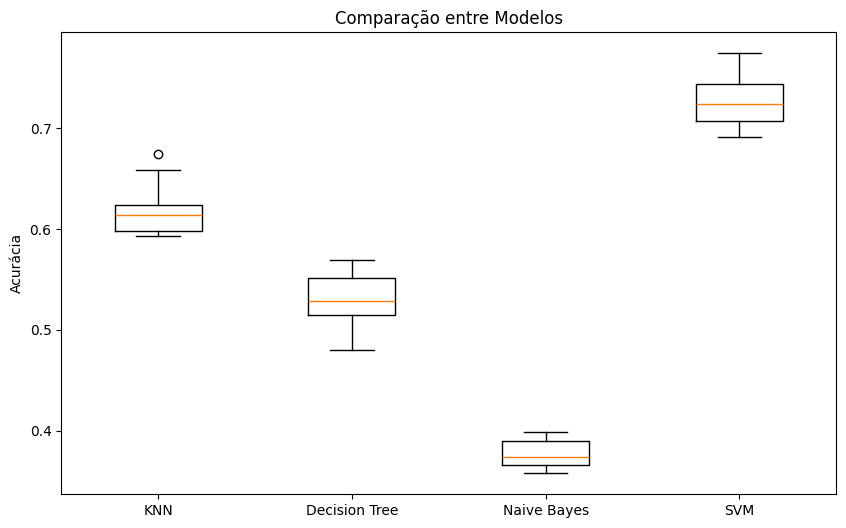

In [70]:
plt.figure(figsize=(10,6))
plt.boxplot(results)
plt.xticks(range(1, len(names)+1), names)
plt.title("Comparação entre Modelos")
plt.ylabel("Acurácia")
plt.show()

## Otimização de Hiperparâmetros

Será utilizado GridSearch para encontrar os melhores parâmetros para o modelo SVM.

In [71]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('svm', SVC())
])

param_grid = {
    'tfidf__max_features': [500, 1000],
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf']
}

grid = GridSearchCV(pipeline, param_grid, cv=kfold, scoring='accuracy')
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best parameters:", grid.best_params_)

Best parameters: {'svm__C': 1, 'svm__kernel': 'linear', 'tfidf__max_features': 1000}


## Avaliação Final no Conjunto de Teste

In [72]:
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6818181818181818

Classification Report:
                  precision    recall  f1-score   support

        fantasy       0.71      0.86      0.77        70
        history       0.94      0.80      0.86        20
         horror       0.25      0.05      0.08        20
     psychology       0.78      0.70      0.74        20
        romance       0.46      0.27      0.34        22
        science       0.92      0.75      0.83        16
science_fiction       1.00      0.11      0.20         9
         sports       0.78      0.44      0.56        16
       thriller       0.61      0.84      0.71        96
         travel       0.80      0.63      0.71        19

       accuracy                           0.68       308
      macro avg       0.72      0.55      0.58       308
   weighted avg       0.68      0.68      0.65       308



## Treinamento Final com Todos os Dados

In [73]:
best_model.fit(X, y)

Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=1000)),
                ('svm', SVC(C=1, kernel='linear'))])

## Exportação do Modelo

In [74]:
joblib.dump(best_model, "./model/modelo_genero_livros.pkl")

['./model/modelo_genero_livros.pkl']

## Teste do Modelo

Foi implementada uma função para testar o modelo treinado com novos dados de entrada. O método recebe como entrada o título e a sinopse de um livro e retorna o gênero previsto pelo modelo.

In [75]:
model = joblib.load("./model/modelo_genero_livros.pkl")

def predict_genre(title, synopsis):
    text = title + " " + synopsis
    prediction = model.predict([text])
    return prediction[0]

tests = [
    {
        "title": "The Rise of Ancient Empires",
        "synopsis": "An in-depth exploration of early civilizations, their cultures, wars, and contributions to modern society."
    },
    {
        "title": "Love in the Time of Silence",
        "synopsis": "A heartfelt story about two strangers who find love while navigating personal loss and emotional healing."
    },
    {
        "title": "The Quantum Paradox",
        "synopsis": "A scientist discovers a way to manipulate time, leading to unexpected consequences that threaten reality itself."
    },
    {
        "title": "The Last Kingdom's Fall",
        "synopsis": "A historical account of a powerful dynasty's decline, marked by betrayal, war, and political intrigue."
    },
    {
        "title": "Mind Over Matter",
        "synopsis": "An analysis of human psychology and how thoughts influence behavior, decision-making, and success."
    },
    {
        "title": "The Haunted Manor",
        "synopsis": "A group of friends spend the night in an abandoned house, only to realize they are not alone."
    },
    {
        "title": "Startup Revolution",
        "synopsis": "Insights into the world of entrepreneurship, innovation, and how startups are shaping the future economy."
    }
]

for i, test in enumerate(tests):
    prediction = predict_genre(test["title"], test["synopsis"])

    print(f"Test {i+1}")
    print("Title:", test["title"])
    print("Predicted genre:", prediction)
    print("-" * 40)

Test 1
Title: The Rise of Ancient Empires
Predicted genre: thriller
----------------------------------------
Test 2
Title: Love in the Time of Silence
Predicted genre: romance
----------------------------------------
Test 3
Title: The Quantum Paradox
Predicted genre: thriller
----------------------------------------
Test 4
Title: The Last Kingdom's Fall
Predicted genre: history
----------------------------------------
Test 5
Title: Mind Over Matter
Predicted genre: psychology
----------------------------------------
Test 6
Title: The Haunted Manor
Predicted genre: horror
----------------------------------------
Test 7
Title: Startup Revolution
Predicted genre: fantasy
----------------------------------------


## Análise de Erros

Alguns exemplos foram classificados incorretamente, especialmente quando diferentes gêneros compartilham vocabulário semelhante.

Isso ocorre porque o TF-IDF considera apenas a frequência de palavras, sem compreender o contexto semântico.

Além disso, o tamanho reduzido da base de dados limita a capacidade de generalização do modelo.